<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/NotebookLM/Module%205/6c_Geographic_Data_and_Maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why we care

A lot of data is inherently location-based and this trend is increasing.  
- Any data that is county, state, country, city, etc. is tied to a geographic location on the ground
- Addresses
- Photos
- Businesses
- Satelite imagery

In order to unlock the full power of this data or to visualize it, we need to really treat it as geographic data.  

Sometimes it's important to do things like:
- Test if an address is within a county
- Aggregate data
- Figure out distances between points


**This lecture will cover:**
- using maps to display data
- other operations on geographic data

# A few mapping basics


**Projections:**  
There are a lot of different projections that are used.  A projection refers to the process used to convert points on the earth (more or less a sphere) to a flat surface like a map or computer monitor.

(This is largely beyond our scope here, but it is can be very important to pay attention to if one is going to do a lot with GIS data.)


**Latitude** is degrees north or south of the equator.  (-90 to 90) Lines of latitude are parallel.

**Longitude** is degrees east or west of the prime meridian (-180 to 180).  Lines of longitude converge at the poles (not parallel).

# Libraries for mapping in Python
There are several choices for libraries for creating maps.  A few of them include:
- matplotblib- basemap - [Geographic Data with Basemap - Python Data Science Handbook](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.13-Geographic-Data-With-Basemap.ipynb)
- Plotly Express - https://plotly.com/python/maps/

- [Altair](https://altair-viz.github.io/gallery/index.html#maps) - Another diverse plotting library that includes some mapping options
- [Folium](https://python-visualization.github.io/folium/) - Specifically for mapping- powerful, interactive maps based on leaflet.js
  

In [1]:
%%capture
%%bash
apt-get update
apt-get install -y tree jq

In [2]:
%%capture
# Get updated version of plotly
!pip install plotly -U

In [3]:
%%capture
!pip install geopandas

In [4]:
import json
import numpy as np
import pandas as pd
import requests
import plotly.express as px
import geopandas as gpd

# COVID Data

**Choropleth** is really just a fancy name for a color-coded map where the color indicates something like population density or the number of positive covid cases.




Make request for the data.

In [5]:
!curl -L -O https://covidtracking.com/data/download/all-states-history.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2674k    0 2674k    0     0  1782k      0 --:--:--  0:00:01 --:--:-- 1784k


In [6]:
!head all-states-history.csv

"date","state","death","deathConfirmed","deathIncrease","deathProbable","hospitalized","hospitalizedCumulative","hospitalizedCurrently","hospitalizedIncrease","inIcuCumulative","inIcuCurrently","negative","negativeIncrease","negativeTestsAntibody","negativeTestsPeopleAntibody","negativeTestsViral","onVentilatorCumulative","onVentilatorCurrently","positive","positiveCasesViral","positiveIncrease","positiveScore","positiveTestsAntibody","positiveTestsAntigen","positiveTestsPeopleAntibody","positiveTestsPeopleAntigen","positiveTestsViral","recovered","totalTestEncountersViral","totalTestEncountersViralIncrease","totalTestResults","totalTestResultsIncrease","totalTestsAntibody","totalTestsAntigen","totalTestsPeopleAntibody","totalTestsPeopleAntigen","totalTestsPeopleViral","totalTestsPeopleViralIncrease","totalTestsViral","totalTestsViralIncrease"
"2021-03-07","AK",305,,0,,1293,1293,33,0,,,,0,,,1660758,,2,56886,,0,0,,,,,68693,,,0,1731628,0,,,,,,0,1731628,0
"2021-03-07","AL",10148,7963,-1,2

In [7]:
%%bash
#Verify that the downloaded data is the same data is in the /Data/ folder
# md5sum /content/drive/MyDrive/Data/all-states-history.csv
curl -L -s https://ddc-datascience.s3.amazonaws.com/all-states-history.csv | md5sum
md5sum all-states-history.csv

9b33482a251e34a59b63c084bffe9c36  -
9b33482a251e34a59b63c084bffe9c36  all-states-history.csv


In [8]:
#Pick one source and read it in.
# covid_csv="/content/drive/MyDrive/Data/all-states-history.csv"
covid_csv="all-states-history.csv"
covid_csv

'all-states-history.csv'

Turn data into data frame and take a peek.

In [9]:
state_df = pd.read_csv(covid_csv)
state_df.head()

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110


See how many entries we have.

In [10]:
state_df.shape

(20780, 41)

In [11]:
state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              20780 non-null  object 
 1   state                             20780 non-null  object 
 2   death                             19930 non-null  float64
 3   deathConfirmed                    9422 non-null   float64
 4   deathIncrease                     20780 non-null  int64  
 5   deathProbable                     7593 non-null   float64
 6   hospitalized                      12382 non-null  float64
 7   hospitalizedCumulative            12382 non-null  float64
 8   hospitalizedCurrently             17339 non-null  float64
 9   hospitalizedIncrease              20780 non-null  int64  
 10  inIcuCumulative                   3789 non-null   float64
 11  inIcuCurrently                    11636 non-null  float64
 12  nega

We have an entry for every day for every state and we just want the most recent data.

In [12]:
type(state_df['date'][0])

str

Dates are currently strings.  We need to turn them into DateTime objects.

In [13]:
state_df['date'] = pd.to_datetime(state_df['date'])
state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              20780 non-null  datetime64[ns]
 1   state                             20780 non-null  object        
 2   death                             19930 non-null  float64       
 3   deathConfirmed                    9422 non-null   float64       
 4   deathIncrease                     20780 non-null  int64         
 5   deathProbable                     7593 non-null   float64       
 6   hospitalized                      12382 non-null  float64       
 7   hospitalizedCumulative            12382 non-null  float64       
 8   hospitalizedCurrently             17339 non-null  float64       
 9   hospitalizedIncrease              20780 non-null  int64         
 10  inIcuCumulative                   3789 non-nul

In [14]:
state_df['date'].sample(n=5, random_state=42)

,date
803,2021-02-21
20402,2020-03-07
19425,2020-03-26
19600,2020-03-22
10246,2020-09-06


Now we have it as a Timestamp

In [15]:
state_df['date'].max()

Timestamp('2021-03-07 00:00:00')

Grab the latest data they do have which is March 7th, 2021.

In [16]:
filter = (state_df['date']==state_df['date'].max())
march_df = state_df[filter]

In [17]:
len(march_df)

56

In [18]:
march_df.head()

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110


In [19]:
march_df.columns

Index(['date', 'state', 'death', 'deathConfirmed', 'deathIncrease',
       'deathProbable', 'hospitalized', 'hospitalizedCumulative',
       'hospitalizedCurrently', 'hospitalizedIncrease', 'inIcuCumulative',
       'inIcuCurrently', 'negative', 'negativeIncrease',
       'negativeTestsAntibody', 'negativeTestsPeopleAntibody',
       'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently',
       'positive', 'positiveCasesViral', 'positiveIncrease', 'positiveScore',
       'positiveTestsAntibody', 'positiveTestsAntigen',
       'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen',
       'positiveTestsViral', 'recovered', 'totalTestEncountersViral',
       'totalTestEncountersViralIncrease', 'totalTestResults',
       'totalTestResultsIncrease', 'totalTestsAntibody', 'totalTestsAntigen',
       'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen',
       'totalTestsPeopleViral', 'totalTestsPeopleViralIncrease',
       'totalTestsViral', 'totalTestsViralIncrease'

## Choropleth Map

In [20]:
fig = px.choropleth(march_df,
                    locations='state',
                    locationmode='USA-states',
                    color='positive',
                    color_continuous_scale="Viridis",
                    scope="usa",
                    labels={'positive':'Positive Tests'}
)

fig.show();

## Choropleth with Animation

Now let's look at April 2020.

In [21]:
#Look at April 2020
filter = ( (state_df['date'] >= '2020-04-01') & (state_df['date'] < '2020-05-01') )
covid_apr = state_df[ filter ]
covid_apr_2 = covid_apr.copy()

#Create new column that is the day of the month
covid_apr_2['day'] = covid_apr['date'].dt.day

#Sort data frame by day
covid_apr_2.sort_values(by = 'day', inplace = True)

In [22]:
covid_apr_2

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease,day
19064,2020-04-01,MI,676.0,765.0,125,35.0,NaN,NaN,NaN,0,...,6133,NaN,NaN,NaN,NaN,NaN,0,43188.0,6133,1
19065,2020-04-01,MN,17.0,NaN,5,NaN,122.0,122.0,54.0,10,...,1002,NaN,NaN,NaN,NaN,NaN,0,NaN,0,1
19066,2020-04-01,MO,18.0,NaN,4,NaN,NaN,NaN,NaN,0,...,2767,NaN,NaN,NaN,NaN,NaN,0,21956.0,2767,1
19067,2020-04-01,MP,1.0,NaN,0,NaN,NaN,NaN,NaN,0,...,4,NaN,NaN,NaN,NaN,NaN,0,NaN,0,1
19068,2020-04-01,MS,22.0,NaN,2,NaN,332.0,332.0,NaN,121,...,311,NaN,NaN,NaN,NaN,NaN,0,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17434,2020-04-30,KS,129.0,NaN,4,NaN,523.0,523.0,NaN,8,...,2168,NaN,NaN,NaN,NaN,NaN,0,NaN,0,30
17433,2020-04-30,IN,1114.0,NaN,49,NaN,NaN,NaN,1466.0,0,...,6239,NaN,NaN,NaN,NaN,NaN,0,127373.0,6239,30
17432,2020-04-30,IL,2355.0,NaN,140,NaN,NaN,NaN,4953.0,0,...,13200,NaN,NaN,NaN,NaN,NaN,0,269867.0,13200,30
17431,2020-04-30,ID,60.0,NaN,0,NaN,175.0,175.0,36.0,2,...,453,NaN,NaN,NaN,NaN,28693.0,453,NaN,0,30


In [23]:
fig = px.choropleth(covid_apr_2,
                    locations='state',
                    locationmode='USA-states',
                    color='hospitalizedCurrently',
                    color_continuous_scale="Viridis",
                    scope="usa",
                    labels={'positive':'Positive Tests'},
                    animation_frame = 'day',
                    range_color=(0, 19000),
)

fig.show();

In [24]:
#Export animation to HTML file for viewing in an HTML page
fig.write_html(file="map.html")

# ABQ Police Incidents

- [APD ArcGIS REST service](https://coagisweb.cabq.gov/arcgis/rest/services/public/APD_Incidents/MapServer/0/query)
- [APD ArcGIS REST Docs](https://coagisweb.cabq.gov/arcgis/sdk/rest/index.html#//02ss0000000r000000)


Import data and take a look at it.

In [25]:
query = 'https://coagisweb.cabq.gov/arcgis/rest/services/public/APD_Incidents/MapServer/0/query?'
attr = '''
  where=1%3D1
  text=
  objectIds=
  time=
  geometry=
  geometryType=esriGeometryEnvelope
  inSR=
  spatialRel=esriSpatialRelIntersects
  relationParam=
  outFields=*
  returnGeometry=true
  maxAllowableOffset=
  geometryPrecision=
  outSR=4326
  returnIdsOnly=false
  returnCountOnly=false
  orderByFields=
  groupByFieldsForStatistics=
  outStatistics=
  returnZ=false
  returnM=false
  gdbVersion=
  returnDistinctValues=false
  f=pjson
'''.split()
incidents_url = query + "&".join(attr)
incidents_url

'https://coagisweb.cabq.gov/arcgis/rest/services/public/APD_Incidents/MapServer/0/query?where=1%3D1&text=&objectIds=&time=&geometry=&geometryType=esriGeometryEnvelope&inSR=&spatialRel=esriSpatialRelIntersects&relationParam=&outFields=*&returnGeometry=true&maxAllowableOffset=&geometryPrecision=&outSR=4326&returnIdsOnly=false&returnCountOnly=false&orderByFields=&groupByFieldsForStatistics=&outStatistics=&returnZ=false&returnM=false&gdbVersion=&returnDistinctValues=false&f=pjson'

Take a look at one entry

In [26]:
#Use curl to fetch the data as JSON
!curl -L "{incidents_url}" > apd.incidents.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:02:13 --:--:--     0
curl: (28) Failed to connect to coagisweb.cabq.gov port 443 after 133962 ms: Connection timed out


In [27]:
#...or download an older copy
!curl -L 'https://ddc-datascience.s3.amazonaws.com/apd.incidents.json' > apd.incidents.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7864k  100 7864k    0     0  3204k      0  0:00:02  0:00:02 --:--:-- 3204k


In [28]:
ls -la apd*

-rw-r--r-- 1 root root 8052827 Jul 15 17:22 apd.incidents.json


In [29]:
#Peak at the first 300 characters
!head -c 300 apd.incidents.json

{
 "displayFieldName": "IncidentType",
 "fieldAliases": {
  "OBJECTID": "OBJECTID",
  "BlockAddress": "Location",
  "IncidentType": "Description",
  "ReportDateTime": "ReportDateTime"
 },
 "geometryType": "esriGeometryPoint",
 "spatialReference": {
  "wkid": 4326,
  "latestWkid": 4326
 },
 "fields":

In [30]:
!jq . apd.incidents.json | head -200

{
  "displayFieldName": "IncidentType",
  "fieldAliases": {
    "OBJECTID": "OBJECTID",
    "BlockAddress": "Location",
    "IncidentType": "Description",
    "ReportDateTime": "ReportDateTime"
  },
  "geometryType": "esriGeometryPoint",
  "spatialReference": {
    "wkid": 4326,
    "latestWkid": 4326
  },
  "fields": [
    {
      "name": "OBJECTID",
      "type": "esriFieldTypeOID",
      "alias": "OBJECTID"
    },
    {
      "name": "BlockAddress",
      "type": "esriFieldTypeString",
      "alias": "Location",
      "length": 60
    },
    {
      "name": "IncidentType",
      "type": "esriFieldTypeString",
      "alias": "Description",
      "length": 250
    },
    {
      "name": "ReportDateTime",
      "type": "esriFieldTypeString",
      "alias": "ReportDateTime",
      "length": 19
    }
  ],
  "features": [
    {
      "attributes": {
        "OBJECTID": 24325018,
        "BlockAddress": "8100 BLOCK JACS LN NE",
        "IncidentType": "WANTED PERSON",
        "ReportDateTi

In [31]:
#Verify that the file downloaded is that same as what's in the data folder (will likely be different with new data)
!ls -la /content/drive/MyDrive/Data/apd.incidents.json apd.incidents.json
!md5sum /content/drive/MyDrive/Data/apd.incidents.json apd.incidents.json

ls: cannot access '/content/drive/MyDrive/Data/apd.incidents.json': No such file or directory
-rw-r--r-- 1 root root 8052827 Jul 15 17:22 apd.incidents.json
md5sum: /content/drive/MyDrive/Data/apd.incidents.json: No such file or directory
c26e0c4a910a1190752c9be758470c97  apd.incidents.json


In [32]:
#Extract the first feature using jq
!jq .features[0] apd.incidents.json

{
  "attributes": {
    "OBJECTID": 24325018,
    "BlockAddress": "8100 BLOCK JACS LN NE",
    "IncidentType": "WANTED PERSON",
    "ReportDateTime": "2022-11-04 10:37:30"
  },
  "geometry": {
    "x": -106.60686434003239,
    "y": 35.17296425434575
  }
}


In [33]:
#Load the data into a Python dictionary
with open("apd.incidents.json") as file:
  incidents_import = json.loads(file.read())

In [34]:
#Look at the keys
incidents_import.keys()

dict_keys(['displayFieldName', 'fieldAliases', 'geometryType', 'spatialReference', 'fields', 'features', 'exceededTransferLimit'])

In [35]:
#Grab the first incident
# incidents_import = requests.get(incidents_url).json()  ## <-- this should have worked, but didn't
features = incidents_import['features']
first = features[0]
first

{'attributes': {'OBJECTID': 24325018,
  'BlockAddress': '8100 BLOCK JACS LN NE',
  'IncidentType': 'WANTED PERSON',
  'ReportDateTime': '2022-11-04 10:37:30'},
 'geometry': {'x': -106.60686434003239, 'y': 35.17296425434575}}

Turn our data into a dataframe and drop NAs.

In [36]:
incidents = pd.DataFrame(features)
incidents.dropna(inplace=True)
incidents.head()

,attributes,geometry
0,"{'OBJECTID': 24325018, 'BlockAddress': '8100 B...","{'x': -106.60686434003239, 'y': 35.17296425434..."
1,"{'OBJECTID': 24325019, 'BlockAddress': '8TH ST...","{'x': -106.65652789095778, 'y': 35.08523481812..."
3,"{'OBJECTID': 24325021, 'BlockAddress': '6900 B...","{'x': -106.69567297659324, 'y': 35.16304735963..."
4,"{'OBJECTID': 24325022, 'BlockAddress': '6100 B...","{'x': -106.7261092315191, 'y': 35.19212793243194}"
5,"{'OBJECTID': 24325023, 'BlockAddress': '6600 B...","{'x': -106.71319030160168, 'y': 35.10527324314..."


In [37]:
incidents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28876 entries, 0 to 29996
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   attributes  28876 non-null  object
 1   geometry    28876 non-null  object
dtypes: object(2)
memory usage: 676.8+ KB


In [38]:
type(incidents.attributes[0])

dict

In [39]:
type(incidents.geometry[0])

dict

Extract data into separate columns.

In [40]:
incidents['geometry'][:10]

,geometry
0,"{'x': -106.60686434003239, 'y': 35.17296425434..."
1,"{'x': -106.65652789095778, 'y': 35.08523481812..."
3,"{'x': -106.69567297659324, 'y': 35.16304735963..."
4,"{'x': -106.7261092315191, 'y': 35.19212793243194}"
5,"{'x': -106.71319030160168, 'y': 35.10527324314..."
6,"{'x': -106.59572308263746, 'y': 35.11950166848..."
7,"{'x': -106.58081960447585, 'y': 35.1030706092392}"
8,"{'x': -106.58162533130194, 'y': 35.10340801945..."
9,"{'x': -106.58070516988842, 'y': 35.10384842027..."
10,"{'x': -106.58273396016037, 'y': 35.10390984647..."


In [41]:
incidents['geometry'][:10].apply(lambda entry: entry['x'])

,geometry
0,-106.606864
1,-106.656528
3,-106.695673
4,-106.726109
5,-106.713190
6,-106.595723
7,-106.580820
8,-106.581625
9,-106.580705
10,-106.582734


In [42]:
incidents['longitude'] = incidents['geometry'].apply(lambda entry: entry['x'])
incidents['latitude'] = incidents['geometry'].apply(lambda entry: entry['y'])
incidents['type'] = incidents['attributes'].apply(lambda entry: entry['IncidentType'])
incidents['address'] = incidents['attributes'].apply(lambda entry: entry['BlockAddress'])
incidents['datetime'] = incidents['attributes'].apply(lambda entry: entry['ReportDateTime'])

incidents.head()


,attributes,geometry,longitude,latitude,type,address,datetime
0,"{'OBJECTID': 24325018, 'BlockAddress': '8100 B...","{'x': -106.60686434003239, 'y': 35.17296425434...",-106.606864,35.172964,WANTED PERSON,8100 BLOCK JACS LN NE,2022-11-04 10:37:30
1,"{'OBJECTID': 24325019, 'BlockAddress': '8TH ST...","{'x': -106.65652789095778, 'y': 35.08523481812...",-106.656528,35.085235,ONSITE DISTURBAN,8TH ST NW / CENTRAL AV NW,2022-11-04 18:53:26
3,"{'OBJECTID': 24325021, 'BlockAddress': '6900 B...","{'x': -106.69567297659324, 'y': 35.16304735963...",-106.695673,35.163047,SUSP PERS/VEHS,6900 BLOCK TAYLOR RANCH DR NW,2022-11-04 13:55:28
4,"{'OBJECTID': 24325022, 'BlockAddress': '6100 B...","{'x': -106.7261092315191, 'y': 35.19212793243194}",-106.726109,35.192128,SUSP PERS/VEHS,6100 BLOCK PARADISE BL NW,2022-11-04 23:29:52
5,"{'OBJECTID': 24325023, 'BlockAddress': '6600 B...","{'x': -106.71319030160168, 'y': 35.10527324314...",-106.713190,35.105273,ONSITE TRAFFIC,6600 BLOCK TIERRA SANDIA CT NW,2022-11-04 14:29:46


In [43]:
incidents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28876 entries, 0 to 29996
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   attributes  28876 non-null  object 
 1   geometry    28876 non-null  object 
 2   longitude   28876 non-null  float64
 3   latitude    28876 non-null  float64
 4   type        28876 non-null  object 
 5   address     28876 non-null  object 
 6   datetime    28876 non-null  object 
dtypes: float64(2), object(5)
memory usage: 2.8+ MB


In [44]:
incidents["datetime"].max()

'2022-11-12 03:32:46'

In [45]:
incidents["type"].value_counts()

,count
type,
SUSP PERS/VEHS,5016
TRAFFIC STOP,4477
DISTURBANCE,4086
ONSITE SUSPICIOU,2250
FAMILY DISPUTE,1806
TRAFF ACC NO INJ,1757
AGGR ASSAULT/BAT,901
THEFT/FRAUD/EMBE,824
ONSITE TRAFFIC,809


In [46]:
incidents["type"].value_counts().sum()

np.int64(28876)

In [47]:
#Take the first 500 incidents (or last 500)
incidents_500 = incidents.sort_values(by = "datetime").iloc[-500:]
incidents_500

,attributes,geometry,longitude,latitude,type,address,datetime
192,"{'OBJECTID': 24325210, 'BlockAddress': '1400 B...","{'x': -106.61390124070824, 'y': 35.13748271419...",-106.613901,35.137483,TRAFF ACC NO INJ,1400 BLOCK RENAISSANCE BL NE,2022-10-31 10:07:44
175,"{'OBJECTID': 24325193, 'BlockAddress': '6000 B...","{'x': -106.68608125107967, 'y': 35.1497590882952}",-106.686081,35.149759,TRAFF ACC NO INJ,6000 BLOCK COORS BL NW,2022-10-31 10:16:25
193,"{'OBJECTID': 24325211, 'BlockAddress': '6300 B...","{'x': -106.63938543471401, 'y': 35.14840542373...",-106.639385,35.148405,TRAFF ACC NO INJ,6300 BLOCK 4TH ST NW,2022-10-31 10:25:09
304,"{'OBJECTID': 24325322, 'BlockAddress': '12200 ...","{'x': -106.50228287979539, 'y': 35.11623790045...",-106.502283,35.116238,FAMILY DISPUTE,12200 BLOCK VICTORIA FALLS DR NE,2022-10-31 10:40:45
194,"{'OBJECTID': 24325212, 'BlockAddress': 'RIO GR...","{'x': -106.66644911941589, 'y': 35.14310931409...",-106.666449,35.143109,TRAFF ACC NO INJ,RIO GRANDE BL NW / MONTANO RD NW,2022-10-31 10:42:27
...,...,...,...,...,...,...,...
503,"{'OBJECTID': 24325521, 'BlockAddress': '900 BL...","{'x': -106.49727659476812, 'y': 35.08211383237...",-106.497277,35.082114,DISTURBANCE,900 BLOCK TRAMWAY BL NE,2022-11-12 01:16:16
130,"{'OBJECTID': 24325148, 'BlockAddress': '11300 ...","{'x': -106.51431284319584, 'y': 35.10704701087...",-106.514313,35.107047,THEFT/FRAUD/EMBE,11300 BLOCK PROSPECT AV NE,2022-11-12 01:20:27
138,"{'OBJECTID': 24325156, 'BlockAddress': '12300 ...","{'x': -106.50164395754113, 'y': 35.11592695105...",-106.501644,35.115927,SHOTS FIRED,12300 BLOCK CANDELARIA RD NE,2022-11-12 03:10:18
232,"{'OBJECTID': 24325250, 'BlockAddress': '900 BL...","{'x': -106.49727659476812, 'y': 35.08211383237...",-106.497277,35.082114,DISTURBANCE,900 BLOCK TRAMWAY BL NE,2022-11-12 03:10:39


## Scatter Mapbox

In [48]:
px.scatter_mapbox?

'open-street-map'`,
    `'white-bg'`, `'carto-positron'`, `'carto-darkmatter'`, `'stamen-
    terrain'`, `'stamen-toner'`, `'stamen-watercolor'

In [49]:
fig = px.scatter_mapbox(incidents_500,
                        lat="latitude",
                        lon="longitude",
                        color = 'type',
                        color_discrete_sequence=px.colors.cyclical.IceFire,
                        zoom = 10,
                        # mapbox_style = 'stamen-watercolor',
                        # mapbox_style = 'carto-positron',
                        mapbox_style = 'open-street-map',
                        )

fig.update_traces(marker={'size': 16})
fig.show()

/tmp/ipykernel_1291/4248116792.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(incidents_500,


## Heatmap

In [50]:
#Just look at loud parties
parties = incidents[incidents['type'].str.contains('LOUD PARTY')].copy()
parties

,attributes,geometry,longitude,latitude,type,address,datetime
16,"{'OBJECTID': 24325034, 'BlockAddress': '10800 ...","{'x': -106.666462086597, 'y': 35.20781071037801}",-106.666462,35.207811,LOUD PARTY,10800 BLOCK CIBOLA LP NW,2022-11-05 00:47:16
45,"{'OBJECTID': 24325063, 'BlockAddress': '400 BL...","{'x': -106.56110221999663, 'y': 35.07021524803...",-106.561102,35.070215,LOUD PARTY,400 BLOCK CHARLESTON ST SE,2022-11-05 00:42:58
47,"{'OBJECTID': 24325065, 'BlockAddress': '1800 B...","{'x': -106.62596879680672, 'y': 35.08021283137...",-106.625969,35.080213,LOUD PARTY,1800 BLOCK GOLD AV SE,2022-11-05 02:22:18
108,"{'OBJECTID': 24325126, 'BlockAddress': '6500 B...","{'x': -106.71659376937988, 'y': 35.17144044025...",-106.716594,35.171440,LOUD PARTY,6500 BLOCK KIMMICK DR NW,2022-11-05 22:24:10
140,"{'OBJECTID': 24325158, 'BlockAddress': '13300 ...","{'x': -106.49868106400245, 'y': 35.09039158055...",-106.498681,35.090392,LOUD PARTY,13300 BLOCK MOUNTAIN RD NE,2022-11-06 03:27:32
...,...,...,...,...,...,...,...
28828,"{'OBJECTID': 24353846, 'BlockAddress': '1300 B...","{'x': -106.63496174397945, 'y': 35.05733987121...",-106.634962,35.057340,LOUD PARTY,1300 BLOCK SPENCE AV SE,2022-06-19 22:36:58
28930,"{'OBJECTID': 24353948, 'BlockAddress': '10200 ...","{'x': -106.74274718401783, 'y': 35.03722504305...",-106.742747,35.037225,LOUD PARTY,10200 BLOCK LONE TREE RD SW,2022-06-19 22:41:47
29386,"{'OBJECTID': 24354404, 'BlockAddress': '11600 ...","{'x': -106.51832667309047, 'y': 35.08016559821...",-106.518327,35.080166,LOUD PARTY,11600 BLOCK MOCHO PL NE,2022-06-20 20:17:31
29389,"{'OBJECTID': 24354407, 'BlockAddress': '1500 B...","{'x': -106.65464834858375, 'y': 35.10001338957...",-106.654648,35.100013,LOUD PARTY,1500 BLOCK 8TH ST NW,2022-06-20 01:30:39


In [51]:
px.density_map?

In [52]:
fig = px.density_map(parties,
                        lat="latitude",
                        lon="longitude",
                        zoom = 12,
                        # mapbox_style="stamen-terrain"
                        map_style = 'open-street-map',
                        )

fig.show()

## United States Census Tracts & Crime

References:
- [United States census - wikipedia]( https://en.wikipedia.org/wiki/United_States_census )
- [US Census American Community Survey - wikipedia]( https://en.wikipedia.org/wiki/American_Community_Survey )
- [US Census website]( https://www.census.gov/)
- [Standard Hierarchy of Census Geographic Entities]( https://www2.census.gov/geo/pdfs/reference/geodiagram.pdf )
- [US Census Data]( https://www.census.gov/data.html )
- [Census Data via FTP]( https://www.census.gov/programs-surveys/acs/data/data-via-ftp.html )
- [Census Data via API]( https://www.census.gov/programs-surveys/acs/data/data-via-api.html )




In [53]:
from math import sqrt

In [54]:
sqrt(2)

1.4142135623730951

In [55]:
import pandas as pd

Census tracts from: https://github.com/arcee123/GIS_GEOJSON_CENSUS_TRACTS

In [56]:
tracts_url = 'https://raw.githubusercontent.com/arcee123/GIS_GEOJSON_CENSUS_TRACTS/master/35.geojson'
tracts = gpd.read_file(tracts_url)
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,35,045,000302,35045000302,3.02,Census Tract 3.02,G5020,S,1.982333e+06,0.0,+36.7410855,-108.1960768,"POLYGON ((-108.20246 36.73413, -108.20244 36.7..."
1,35,057,963600,35057963600,9636,Census Tract 9636,G5020,S,2.838602e+09,1625745.0,+34.8062003,-105.9554829,"POLYGON ((-106.46648 34.70984, -106.46625 34.7..."
2,35,057,963700,35057963700,9637,Census Tract 9637,G5020,S,5.508878e+09,673409.0,+34.4902108,-105.7622334,"POLYGON ((-106.47107 34.60886, -106.47098 34.6..."
3,35,001,004501,35001004501,45.01,Census Tract 45.01,G5020,S,2.230592e+06,316567.0,+35.0417938,-106.6726985,"POLYGON ((-106.6804 35.02692, -106.68038 35.02..."
4,35,001,004402,35001004402,44.02,Census Tract 44.02,G5020,S,5.102802e+06,630.0,+35.0398987,-106.6993998,"POLYGON ((-106.71401 35.02726, -106.71388 35.0..."


In [57]:
tracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   499 non-null    object  
 1   COUNTYFP  499 non-null    object  
 2   TRACTCE   499 non-null    object  
 3   GEOID     499 non-null    object  
 4   NAME      499 non-null    object  
 5   NAMELSAD  499 non-null    object  
 6   MTFCC     499 non-null    object  
 7   FUNCSTAT  499 non-null    object  
 8   ALAND     499 non-null    float64 
 9   AWATER    499 non-null    float64 
 10  INTPTLAT  499 non-null    object  
 11  INTPTLON  499 non-null    object  
 12  geometry  499 non-null    geometry
dtypes: float64(2), geometry(1), object(10)
memory usage: 50.8+ KB


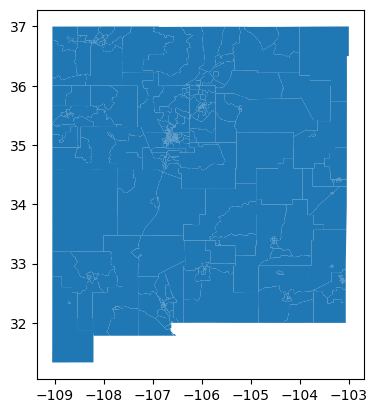

In [58]:
tracts.plot();

In [59]:
parties.head()

,attributes,geometry,longitude,latitude,type,address,datetime
16,"{'OBJECTID': 24325034, 'BlockAddress': '10800 ...","{'x': -106.666462086597, 'y': 35.20781071037801}",-106.666462,35.207811,LOUD PARTY,10800 BLOCK CIBOLA LP NW,2022-11-05 00:47:16
45,"{'OBJECTID': 24325063, 'BlockAddress': '400 BL...","{'x': -106.56110221999663, 'y': 35.07021524803...",-106.561102,35.070215,LOUD PARTY,400 BLOCK CHARLESTON ST SE,2022-11-05 00:42:58
47,"{'OBJECTID': 24325065, 'BlockAddress': '1800 B...","{'x': -106.62596879680672, 'y': 35.08021283137...",-106.625969,35.080213,LOUD PARTY,1800 BLOCK GOLD AV SE,2022-11-05 02:22:18
108,"{'OBJECTID': 24325126, 'BlockAddress': '6500 B...","{'x': -106.71659376937988, 'y': 35.17144044025...",-106.716594,35.171440,LOUD PARTY,6500 BLOCK KIMMICK DR NW,2022-11-05 22:24:10
140,"{'OBJECTID': 24325158, 'BlockAddress': '13300 ...","{'x': -106.49868106400245, 'y': 35.09039158055...",-106.498681,35.090392,LOUD PARTY,13300 BLOCK MOUNTAIN RD NE,2022-11-06 03:27:32


In [60]:
parties.rename(columns={"geometry":"location"}, inplace=True)
parties.head()

,attributes,location,longitude,latitude,type,address,datetime
16,"{'OBJECTID': 24325034, 'BlockAddress': '10800 ...","{'x': -106.666462086597, 'y': 35.20781071037801}",-106.666462,35.207811,LOUD PARTY,10800 BLOCK CIBOLA LP NW,2022-11-05 00:47:16
45,"{'OBJECTID': 24325063, 'BlockAddress': '400 BL...","{'x': -106.56110221999663, 'y': 35.07021524803...",-106.561102,35.070215,LOUD PARTY,400 BLOCK CHARLESTON ST SE,2022-11-05 00:42:58
47,"{'OBJECTID': 24325065, 'BlockAddress': '1800 B...","{'x': -106.62596879680672, 'y': 35.08021283137...",-106.625969,35.080213,LOUD PARTY,1800 BLOCK GOLD AV SE,2022-11-05 02:22:18
108,"{'OBJECTID': 24325126, 'BlockAddress': '6500 B...","{'x': -106.71659376937988, 'y': 35.17144044025...",-106.716594,35.171440,LOUD PARTY,6500 BLOCK KIMMICK DR NW,2022-11-05 22:24:10
140,"{'OBJECTID': 24325158, 'BlockAddress': '13300 ...","{'x': -106.49868106400245, 'y': 35.09039158055...",-106.498681,35.090392,LOUD PARTY,13300 BLOCK MOUNTAIN RD NE,2022-11-06 03:27:32


In [61]:
parties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159 entries, 16 to 29537
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   attributes  159 non-null    object 
 1   location    159 non-null    object 
 2   longitude   159 non-null    float64
 3   latitude    159 non-null    float64
 4   type        159 non-null    object 
 5   address     159 non-null    object 
 6   datetime    159 non-null    object 
dtypes: float64(2), object(5)
memory usage: 14.0+ KB


In [62]:
# Create geometry for parties data
parties_geo = gpd.GeoDataFrame(
    parties,
    geometry=gpd.points_from_xy(
        parties.longitude,
        parties.latitude
    )
)
parties_geo.head()


,attributes,location,longitude,latitude,type,address,datetime,geometry
16,"{'OBJECTID': 24325034, 'BlockAddress': '10800 ...","{'x': -106.666462086597, 'y': 35.20781071037801}",-106.666462,35.207811,LOUD PARTY,10800 BLOCK CIBOLA LP NW,2022-11-05 00:47:16,POINT (-106.66646 35.20781)
45,"{'OBJECTID': 24325063, 'BlockAddress': '400 BL...","{'x': -106.56110221999663, 'y': 35.07021524803...",-106.561102,35.070215,LOUD PARTY,400 BLOCK CHARLESTON ST SE,2022-11-05 00:42:58,POINT (-106.5611 35.07022)
47,"{'OBJECTID': 24325065, 'BlockAddress': '1800 B...","{'x': -106.62596879680672, 'y': 35.08021283137...",-106.625969,35.080213,LOUD PARTY,1800 BLOCK GOLD AV SE,2022-11-05 02:22:18,POINT (-106.62597 35.08021)
108,"{'OBJECTID': 24325126, 'BlockAddress': '6500 B...","{'x': -106.71659376937988, 'y': 35.17144044025...",-106.716594,35.171440,LOUD PARTY,6500 BLOCK KIMMICK DR NW,2022-11-05 22:24:10,POINT (-106.71659 35.17144)
140,"{'OBJECTID': 24325158, 'BlockAddress': '13300 ...","{'x': -106.49868106400245, 'y': 35.09039158055...",-106.498681,35.090392,LOUD PARTY,13300 BLOCK MOUNTAIN RD NE,2022-11-06 03:27:32,POINT (-106.49868 35.09039)


In [63]:
parties_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 159 entries, 16 to 29537
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   attributes  159 non-null    object  
 1   location    159 non-null    object  
 2   longitude   159 non-null    float64 
 3   latitude    159 non-null    float64 
 4   type        159 non-null    object  
 5   address     159 non-null    object  
 6   datetime    159 non-null    object  
 7   geometry    159 non-null    geometry
dtypes: float64(2), geometry(1), object(5)
memory usage: 15.2+ KB


See if a point is inside a tract polygon

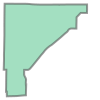

In [64]:
tracts.iloc[0]['geometry']

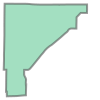

In [65]:
tracts['geometry'].iloc[0]

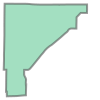

In [66]:
tracts['geometry'][0]

In [67]:
tracts0 = tracts.geometry.iloc[0]
parties0 = parties_geo.geometry.iloc[0]

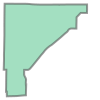

In [68]:
tracts0

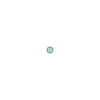

In [69]:
parties0

In [70]:
tracts0.contains(parties0)

False

In [71]:
dict(enumerate(dir(tracts0)))

{0: '__and__',
 1: '__bool__',
 2: '__class__',
 3: '__delattr__',
 4: '__dir__',
 5: '__doc__',
 6: '__eq__',
 7: '__format__',
 8: '__ge__',
 9: '__geo_interface__',
 10: '__getattribute__',
 11: '__getstate__',
 12: '__gt__',
 13: '__hash__',
 14: '__init__',
 15: '__init_subclass__',
 16: '__le__',
 17: '__lt__',
 18: '__module__',
 19: '__ne__',
 20: '__new__',
 21: '__nonzero__',
 22: '__or__',
 23: '__reduce__',
 24: '__reduce_ex__',
 25: '__repr__',
 26: '__setattr__',
 27: '__setstate__',
 28: '__sizeof__',
 29: '__slots__',
 30: '__str__',
 31: '__sub__',
 32: '__subclasshook__',
 33: '__xor__',
 34: '_geom',
 35: '_geom_prepared',
 36: '_ndim',
 37: '_repr_svg_',
 38: 'area',
 39: 'boundary',
 40: 'bounds',
 41: 'buffer',
 42: 'centroid',
 43: 'contains',
 44: 'contains_properly',
 45: 'convex_hull',
 46: 'coords',
 47: 'covered_by',
 48: 'covers',
 49: 'crosses',
 50: 'difference',
 51: 'disjoint',
 52: 'distance',
 53: 'dwithin',
 54: 'envelope',
 55: 'equals',
 56: 'equal

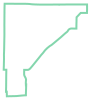

In [72]:
getattr(tracts0, "exterior" )

In [73]:
#All the methods/attributes
[x for x in dir(tracts0) if '_' not in x]

['area',
 'boundary',
 'bounds',
 'buffer',
 'centroid',
 'contains',
 'coords',
 'covers',
 'crosses',
 'difference',
 'disjoint',
 'distance',
 'dwithin',
 'envelope',
 'equals',
 'exterior',
 'geometryType',
 'interiors',
 'interpolate',
 'intersection',
 'intersects',
 'length',
 'normalize',
 'overlaps',
 'project',
 'relate',
 'reverse',
 'segmentize',
 'simplify',
 'svg',
 'touches',
 'type',
 'union',
 'within',
 'wkb',
 'wkt',
 'xy']

In [74]:
type(tracts0)

shapely.geometry.polygon.Polygon

In [75]:
type(parties0)

shapely.geometry.point.Point

Find the centroid

In [76]:
print(tracts0.centroid)

POINT (-108.19607648249088 36.741085756281294)


Pull out lat or long for a point

In [77]:
[x for x in dir(parties0) if '_' not in x]

['area',
 'boundary',
 'bounds',
 'buffer',
 'centroid',
 'contains',
 'coords',
 'covers',
 'crosses',
 'difference',
 'disjoint',
 'distance',
 'dwithin',
 'envelope',
 'equals',
 'geometryType',
 'interpolate',
 'intersection',
 'intersects',
 'length',
 'm',
 'normalize',
 'overlaps',
 'project',
 'relate',
 'reverse',
 'segmentize',
 'simplify',
 'svg',
 'touches',
 'type',
 'union',
 'within',
 'wkb',
 'wkt',
 'x',
 'xy',
 'y',
 'z']

In [78]:
parties0.x

-106.666462086597

In [79]:
parties0.y

35.20781071037801

Distance between points

In [80]:
parties1 = parties_geo.geometry.iloc[1]

In [81]:
import geopy.distance

In [82]:
dist = geopy.distance.geodesic((parties0.y, parties0.x), (parties1.y, parties1.x))
dist.kilometers

18.033945813276596

In [83]:
dist.miles

11.205774410739155

### Count the number of loud party incidents in each tract ... using a for-loop.

In [84]:
parties

,attributes,location,longitude,latitude,type,address,datetime
16,"{'OBJECTID': 24325034, 'BlockAddress': '10800 ...","{'x': -106.666462086597, 'y': 35.20781071037801}",-106.666462,35.207811,LOUD PARTY,10800 BLOCK CIBOLA LP NW,2022-11-05 00:47:16
45,"{'OBJECTID': 24325063, 'BlockAddress': '400 BL...","{'x': -106.56110221999663, 'y': 35.07021524803...",-106.561102,35.070215,LOUD PARTY,400 BLOCK CHARLESTON ST SE,2022-11-05 00:42:58
47,"{'OBJECTID': 24325065, 'BlockAddress': '1800 B...","{'x': -106.62596879680672, 'y': 35.08021283137...",-106.625969,35.080213,LOUD PARTY,1800 BLOCK GOLD AV SE,2022-11-05 02:22:18
108,"{'OBJECTID': 24325126, 'BlockAddress': '6500 B...","{'x': -106.71659376937988, 'y': 35.17144044025...",-106.716594,35.171440,LOUD PARTY,6500 BLOCK KIMMICK DR NW,2022-11-05 22:24:10
140,"{'OBJECTID': 24325158, 'BlockAddress': '13300 ...","{'x': -106.49868106400245, 'y': 35.09039158055...",-106.498681,35.090392,LOUD PARTY,13300 BLOCK MOUNTAIN RD NE,2022-11-06 03:27:32
...,...,...,...,...,...,...,...
28828,"{'OBJECTID': 24353846, 'BlockAddress': '1300 B...","{'x': -106.63496174397945, 'y': 35.05733987121...",-106.634962,35.057340,LOUD PARTY,1300 BLOCK SPENCE AV SE,2022-06-19 22:36:58
28930,"{'OBJECTID': 24353948, 'BlockAddress': '10200 ...","{'x': -106.74274718401783, 'y': 35.03722504305...",-106.742747,35.037225,LOUD PARTY,10200 BLOCK LONE TREE RD SW,2022-06-19 22:41:47
29386,"{'OBJECTID': 24354404, 'BlockAddress': '11600 ...","{'x': -106.51832667309047, 'y': 35.08016559821...",-106.518327,35.080166,LOUD PARTY,11600 BLOCK MOCHO PL NE,2022-06-20 20:17:31
29389,"{'OBJECTID': 24354407, 'BlockAddress': '1500 B...","{'x': -106.65464834858375, 'y': 35.10001338957...",-106.654648,35.100013,LOUD PARTY,1500 BLOCK 8TH ST NW,2022-06-20 01:30:39


In [85]:
zfoo = np.full(len(tracts), 0)

for idx, incident in parties_geo.iterrows():
  for idx, tract in tracts.iterrows():
    if tract['geometry'].contains(incident['geometry']):
      zfoo[idx] += 1
      break

tracts['incidents'] = zfoo

In [86]:
tracts

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,incidents
0,35,045,000302,35045000302,3.02,Census Tract 3.02,G5020,S,1.982333e+06,0.0,+36.7410855,-108.1960768,"POLYGON ((-108.20246 36.73413, -108.20244 36.7...",0
1,35,057,963600,35057963600,9636,Census Tract 9636,G5020,S,2.838602e+09,1625745.0,+34.8062003,-105.9554829,"POLYGON ((-106.46648 34.70984, -106.46625 34.7...",0
2,35,057,963700,35057963700,9637,Census Tract 9637,G5020,S,5.508878e+09,673409.0,+34.4902108,-105.7622334,"POLYGON ((-106.47107 34.60886, -106.47098 34.6...",0
3,35,001,004501,35001004501,45.01,Census Tract 45.01,G5020,S,2.230592e+06,316567.0,+35.0417938,-106.6726985,"POLYGON ((-106.6804 35.02692, -106.68038 35.02...",0
4,35,001,004402,35001004402,44.02,Census Tract 44.02,G5020,S,5.102802e+06,630.0,+35.0398987,-106.6993998,"POLYGON ((-106.71401 35.02726, -106.71388 35.0...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,35,035,000401,35035000401,4.01,Census Tract 4.01,G5020,S,4.451207e+06,757.0,+32.8978364,-105.9251430,"POLYGON ((-105.94372 32.89107, -105.94358 32.8...",0
495,35,035,000402,35035000402,4.02,Census Tract 4.02,G5020,S,3.410180e+07,3331.0,+32.8558000,-105.9412659,"POLYGON ((-105.97501 32.81568, -105.97403 32.8...",0
496,35,035,000200,35035000200,2,Census Tract 2,G5020,S,1.368838e+06,0.0,+32.9039720,-105.9525268,"POLYGON ((-105.96055 32.90797, -105.96036 32.9...",0
497,35,035,000100,35035000100,1,Census Tract 1,G5020,S,2.061019e+06,627.0,+32.8965488,-105.9506418,"POLYGON ((-105.96141 32.89995, -105.96122 32.8...",0


In [87]:
filter = tracts['incidents'] > 4
tracts[filter]

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,incidents
28,35,001,004748,35001004748,47.48,Census Tract 47.48,G5020,S,3422983.0,29193.0,+35.1982107,-106.7378708,"POLYGON ((-106.75235 35.20291, -106.75203 35.2...",5
325,35,001,004741,35001004741,47.41,Census Tract 47.41,G5020,S,7085817.0,13140.0,+35.0869206,-106.7234573,"POLYGON ((-106.74657 35.08597, -106.74177 35.0...",6
382,35,001,002200,35001002200,22,Census Tract 22,G5020,S,2588049.0,448752.0,+35.0845439,-106.6682329,"POLYGON ((-106.68117 35.08907, -106.68092 35.0...",5
394,35,001,001200,35001001200,12,Census Tract 12,G5020,S,11871558.0,10857.0,+35.0514383,-106.6262814,"POLYGON ((-106.63994 35.07402, -106.63993 35.0...",5
398,35,001,002402,35001002402,24.02,Census Tract 24.02,G5020,S,2832006.0,0.0,+35.0816423,-106.7044929,"POLYGON ((-106.71082 35.08306, -106.71082 35.0...",5


In [88]:
parties_geo.shape, tracts.shape

((159, 8), (499, 14))

### Using spatial join: sjoin


In [89]:
gpd.sjoin?

In [90]:
parties_geo.sindex.valid_query_predicates

{None,
 'contains',
 'contains_properly',
 'covered_by',
 'covers',
 'crosses',
 'dwithin',
 'intersects',
 'overlaps',
 'touches',
 'within'}

In [91]:
#Create DF of tracts that have parties
joined_gpd = gpd.sjoin(
    left_df = parties_geo.set_crs(tracts.crs, allow_override = True),
    right_df = tracts,
    how = "inner",
    predicate = "within",
)

In [92]:
joined_gpd.shape

(159, 22)

In [93]:
joined_gpd.columns

Index(['attributes', 'location', 'longitude', 'latitude', 'type', 'address',
       'datetime', 'geometry', 'index_right', 'STATEFP', 'COUNTYFP', 'TRACTCE',
       'GEOID', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'incidents'],
      dtype='object')

In [94]:
joined_gpd.head()

,attributes,location,longitude,latitude,type,address,datetime,geometry,index_right,STATEFP,...,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,incidents
16,"{'OBJECTID': 24325034, 'BlockAddress': '10800 ...","{'x': -106.666462086597, 'y': 35.20781071037801}",-106.666462,35.207811,LOUD PARTY,10800 BLOCK CIBOLA LP NW,2022-11-05 00:47:16,POINT (-106.66646 35.20781),12,35,...,35001004717,47.17,Census Tract 47.17,G5020,S,3358590.0,44047.0,+35.2074044,-106.6681287,2
45,"{'OBJECTID': 24325063, 'BlockAddress': '400 BL...","{'x': -106.56110221999663, 'y': 35.07021524803...",-106.561102,35.070215,LOUD PARTY,400 BLOCK CHARLESTON ST SE,2022-11-05 00:42:58,POINT (-106.5611 35.07022),389,35,...,35001000901,9.01,Census Tract 9.01,G5020,S,1568927.0,0.0,+35.0682041,-106.5605737,2
47,"{'OBJECTID': 24325065, 'BlockAddress': '1800 B...","{'x': -106.62596879680672, 'y': 35.08021283137...",-106.625969,35.080213,LOUD PARTY,1800 BLOCK GOLD AV SE,2022-11-05 02:22:18,POINT (-106.62597 35.08021),156,35,...,35001001600,16,Census Tract 16,G5020,S,995605.0,0.0,+35.0801363,-106.6307197,4
108,"{'OBJECTID': 24325126, 'BlockAddress': '6500 B...","{'x': -106.71659376937988, 'y': 35.17144044025...",-106.716594,35.171440,LOUD PARTY,6500 BLOCK KIMMICK DR NW,2022-11-05 22:24:10,POINT (-106.71659 35.17144),121,35,...,35001940600,9406,Census Tract 9406,G5020,S,987545414.0,2848940.0,+35.1042041,-106.9753782,1
140,"{'OBJECTID': 24325158, 'BlockAddress': '13300 ...","{'x': -106.49868106400245, 'y': 35.09039158055...",-106.498681,35.090392,LOUD PARTY,13300 BLOCK MOUNTAIN RD NE,2022-11-06 03:27:32,POINT (-106.49868 35.09039),357,35,...,35001000129,1.29,Census Tract 1.29,G5020,S,1324535.0,0.0,+35.0902019,-106.5059112,2


#### Count number of parties per tract

In [95]:
pd.Series.reset_index

<function pandas.core.series.Series.reset_index(self, level: 'IndexLabel | None' = None, *, drop: 'bool' = False, name: 'Level' = <no_default>, inplace: 'bool' = False, allow_duplicates: 'bool' = False) -> 'DataFrame | Series | None'>

In [96]:
incident_counts_df = joined_gpd["GEOID"].value_counts().reset_index(name = "party_count")
incident_counts_df

,GEOID,party_count
0,35001004741,6
1,35001004748,5
2,35001001200,5
3,35001002402,5
4,35001002200,5
...,...,...
80,35001001800,1
81,35001000708,1
82,35001004742,1
83,35001000124,1


#### Merge tracts with party counts per tract

In [97]:
tracts.merge(incident_counts_df, how="left", on="GEOID").sort_values( by = ["party_count"], ascending = False ).fillna("0")

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,incidents,party_count
325,35,001,004741,35001004741,47.41,Census Tract 47.41,G5020,S,7085817.0,13140.0,+35.0869206,-106.7234573,"POLYGON ((-106.74657 35.08597, -106.74177 35.0...",6,6.0
382,35,001,002200,35001002200,22,Census Tract 22,G5020,S,2588049.0,448752.0,+35.0845439,-106.6682329,"POLYGON ((-106.68117 35.08907, -106.68092 35.0...",5,5.0
394,35,001,001200,35001001200,12,Census Tract 12,G5020,S,11871558.0,10857.0,+35.0514383,-106.6262814,"POLYGON ((-106.63994 35.07402, -106.63993 35.0...",5,5.0
398,35,001,002402,35001002402,24.02,Census Tract 24.02,G5020,S,2832006.0,0.0,+35.0816423,-106.7044929,"POLYGON ((-106.71082 35.08306, -106.71082 35.0...",5,5.0
28,35,001,004748,35001004748,47.48,Census Tract 47.48,G5020,S,3422983.0,29193.0,+35.1982107,-106.7378708,"POLYGON ((-106.75235 35.20291, -106.75203 35.2...",5,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,35,035,000401,35035000401,4.01,Census Tract 4.01,G5020,S,4451207.0,757.0,+32.8978364,-105.9251430,"POLYGON ((-105.94372 32.89107, -105.94358 32.8...",0,0
495,35,035,000402,35035000402,4.02,Census Tract 4.02,G5020,S,34101797.0,3331.0,+32.8558000,-105.9412659,"POLYGON ((-105.97501 32.81568, -105.97403 32.8...",0,0
496,35,035,000200,35035000200,2,Census Tract 2,G5020,S,1368838.0,0.0,+32.9039720,-105.9525268,"POLYGON ((-105.96055 32.90797, -105.96036 32.9...",0,0
497,35,035,000100,35035000100,1,Census Tract 1,G5020,S,2061019.0,627.0,+32.8965488,-105.9506418,"POLYGON ((-105.96141 32.89995, -105.96122 32.8...",0,0


Keep tracks that have had at least one incident

In [98]:
tracts_abq = tracts[tracts['incidents'] != 0].copy()
tracts_abq.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,incidents
5,35,001,004713,35001004713,47.13,Census Tract 47.13,G5020,S,2825492.0,0.0,+35.0486331,-106.7488369,"POLYGON ((-106.76014 35.0554, -106.75882 35.05...",1
6,35,001,004712,35001004712,47.12,Census Tract 47.12,G5020,S,6931475.0,24374.0,+35.0680642,-106.7583700,"POLYGON ((-106.7918 35.06324, -106.79114 35.06...",2
7,35,001,004726,35001004726,47.26,Census Tract 47.26,G5020,S,1561334.0,0.0,+35.1467775,-106.7181869,"POLYGON ((-106.72562 35.14581, -106.72533 35.1...",1
8,35,001,004728,35001004728,47.28,Census Tract 47.28,G5020,S,2653792.0,0.0,+35.1424651,-106.7010213,"POLYGON ((-106.71246 35.14508, -106.71159 35.1...",4
10,35,001,004729,35001004729,47.29,Census Tract 47.29,G5020,S,4624664.0,435488.0,+35.1320653,-106.6950082,"POLYGON ((-106.70388 35.10791, -106.70367 35.1...",1


In [99]:
tracts_abq.set_index('TRACTCE', inplace = True)

In [100]:
tracts_abq

,STATEFP,COUNTYFP,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,incidents
TRACTCE,,,,,,,,,,,,,
004713,35,001,35001004713,47.13,Census Tract 47.13,G5020,S,2825492.0,0.0,+35.0486331,-106.7488369,"POLYGON ((-106.76014 35.0554, -106.75882 35.05...",1
004712,35,001,35001004712,47.12,Census Tract 47.12,G5020,S,6931475.0,24374.0,+35.0680642,-106.7583700,"POLYGON ((-106.7918 35.06324, -106.79114 35.06...",2
004726,35,001,35001004726,47.26,Census Tract 47.26,G5020,S,1561334.0,0.0,+35.1467775,-106.7181869,"POLYGON ((-106.72562 35.14581, -106.72533 35.1...",1
004728,35,001,35001004728,47.28,Census Tract 47.28,G5020,S,2653792.0,0.0,+35.1424651,-106.7010213,"POLYGON ((-106.71246 35.14508, -106.71159 35.1...",4
004729,35,001,35001004729,47.29,Census Tract 47.29,G5020,S,4624664.0,435488.0,+35.1320653,-106.6950082,"POLYGON ((-106.70388 35.10791, -106.70367 35.1...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
003719,35,001,35001003719,37.19,Census Tract 37.19,G5020,S,2594156.0,0.0,+35.1346147,-106.5126321,"POLYGON ((-106.53338 35.13471, -106.53339 35.1...",1
003728,35,001,35001003728,37.28,Census Tract 37.28,G5020,S,1619608.0,0.0,+35.1408168,-106.5251236,"POLYGON ((-106.5334 35.13729, -106.5334 35.137...",2
001700,35,001,35001001700,17,Census Tract 17,G5020,S,2048194.0,0.0,+35.0792854,-106.6127406,"POLYGON ((-106.62411 35.07405, -106.62408 35.0...",2


In [101]:
fig = px.choropleth_map(tracts_abq,
                            geojson = tracts_abq.geometry,
                            locations=tracts_abq.index,
                            color='incidents',
                            color_continuous_scale="Viridis",
                            map_style = 'carto-positron',
                            zoom = 10,
                            center = {"lat": 35.0844, "lon": -106.6504},
                            opacity = .7
                           )

fig.update_geos(fitbounds="locations", visible=False)
fig.show()